# **Serverless Function Cost and Performance Predictor**

This notebook analyzes real-world serverless function invocation data from Microsoft Azure Functions (2019 public trace) to understand invocation patterns and build a machine learning model that predicts function-level workload characteristics.

Dataset Source: Azure Functions Dataset 2019, released publicly by Microsoft for research purposes.
Kaggle Mirror: https://www.kaggle.com/datasets/theodoram/azure-2019-public-dataset

### **Objectives**
1. Load and explore Azure Functions invocation data
2. Analyze invocation frequency patterns across functions and applications
3. Engineer features that relate to cost and performance
4. Build a predictive model for function invocation load
5. Summarize findings and business relevance

## **Step 1: Environment Setup and Dataset Download**

In this step, we install the Kaggle API, upload our Kaggle credentials, and download the dataset directly into Google Colab.

In [1]:
!pip install kaggle --quiet

from google.colab import files
files.upload()

print("Kaggle API key configured successfully.")

Saving kaggle.json to kaggle.json
Kaggle API key configured successfully.


In [2]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/')
os.system('chmod 600 /root/.kaggle/kaggle.json')

!kaggle datasets download -d theodoram/azure-2019-public-dataset

Dataset URL: https://www.kaggle.com/datasets/theodoram/azure-2019-public-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 428M/428M [00:03<00:00, 131MB/s] 



In [3]:
import zipfile

with zipfile.ZipFile('azure-2019-public-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('azure_2019_data')

print("Dataset extracted successfully")

Dataset extracted successfully


In [4]:
for root, dirs, files_list in os.walk('azure_2019_data'):
    for file in files_list:
        print(os.path.join(root, file))

azure_2019_data/day1_iit_hist_df.feather
azure_2019_data/azure-functions-dataset-2019/function_durations_percentiles.feather
azure_2019_data/azure-functions-dataset-2019/app_memory_percentiles.feather
azure_2019_data/azure-functions-dataset-2019/invocations_per_function_md.feather


# **Step 2: (DuckDB Approach) Loading Invocation Data**

The invocations_per_function_md.feather file contains 1440 minute-level columns, which can exceed available memory when loaded directly into pandas. To handle this efficiently, we use DuckDB, an in-process analytical database that can query the feather file directly from disk and aggregate it before bringing results into memory. This avoids loading the full raw dataset while preserving all necessary information for analysis.

In [5]:
!ls -lh azure_2019_data/azure-functions-dataset-2019/

total 797M
-rw-r--r-- 1 root root  29M Jul 11 10:17 app_memory_percentiles.feather
-rw-r--r-- 1 root root 118M Jul 11 10:17 function_durations_percentiles.feather
-rw-r--r-- 1 root root 651M Jul 11 10:17 invocations_per_function_md.feather


In [6]:
import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print(f"Total RAM available: {ram_gb:.2f} GB")

import pyarrow.feather as feather

schema = feather.read_table('azure_2019_data/azure-functions-dataset-2019/invocations_per_function_md.feather', memory_map=True).schema
print(f"\nNumber of columns: {len(schema)}")
print(f"\nFirst 10 column names:")
print(schema.names[:10])

Total RAM available: 13.61 GB

Number of columns: 1445

First 10 column names:
['HashOwner', 'HashApp', 'HashFunction', 'Trigger', '1', '2', '3', '4', '5', '6']


In [7]:
import duckdb
import pyarrow.feather as feather

con = duckdb.connect()

arrow_table = feather.read_table(
    'azure_2019_data/azure-functions-dataset-2019/invocations_per_function_md.feather',
    memory_map=True
)

con.register('invocations_raw', arrow_table)

query = """
SELECT
    HashOwner,
    HashApp,
    HashFunction,
    Trigger
FROM invocations_raw
LIMIT 5
"""

sample_df = con.execute(query).df()
sample_df

,HashOwner,HashApp,HashFunction,Trigger
0,71ca12c7af70d021e285b51b245942f8432df6463ff9f2...,7ca324d9fc836a5d4562811c11ce3719530ee919dd1fb9...,520dbd6bd906840012aa0c4b778743efc7c0ac7b7caf96...,http
1,71ca12c7af70d021e285b51b245942f8432df6463ff9f2...,0d0ac65651f54ae3285a59564d64e39238b516fa1d5b56...,115ca7a2b5bc290052c3da74cd0347d19c3c67b7d5aa66...,http
2,71ca12c7af70d021e285b51b245942f8432df6463ff9f2...,a04487a6ba1e14296eb7647e4963180d28bef7a90a8fc5...,93e6c664773bbec3a7f50a0e92fa7e97401a802dc6eed8...,orchestration
3,71ca12c7af70d021e285b51b245942f8432df6463ff9f2...,a04487a6ba1e14296eb7647e4963180d28bef7a90a8fc5...,740c5c767e4b9978ee59a97d1829cfbaf755a47806a311...,http
4,71ca12c7af70d021e285b51b245942f8432df6463ff9f2...,a04487a6ba1e14296eb7647e4963180d28bef7a90a8fc5...,c108b4864b866b38b80d0e4594cc6d038f39668b804a1b...,http


## **Step 2.1: Aggregating Invocation Statistics**

Rather than working with 1440 individual minute-level columns, we aggregate each function's invocation pattern into summary statistics: total invocations, average invocations per minute, peak invocations, and variability. This transforms the wide time-series format into a compact, analysis-ready feature set while preserving the essential workload characteristics of each function.

In [8]:
con.execute("SET max_expression_depth TO 10000")

minute_columns = [col for col in arrow_table.column_names if col not in ['HashOwner', 'HashApp', 'HashFunction', 'Trigger']]

sum_expr = " + ".join([f'"{col}"' for col in minute_columns])
greatest_expr = f"GREATEST({', '.join([chr(34) + col + chr(34) for col in minute_columns])})"

query = f"""
SELECT
    HashOwner,
    HashApp,
    HashFunction,
    Trigger,
    ({sum_expr}) AS total_invocations,
    ({sum_expr}) / 1440.0 AS avg_invocations_per_min,
    {greatest_expr} AS max_invocations_per_min
FROM invocations_raw
"""

function_summary_df = con.execute(query).df()

print("Shape:", function_summary_df.shape)
print("\nMemory usage:")
print(f"{function_summary_df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print("\nFirst 5 rows:")
function_summary_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Shape: (618545, 7)

Memory usage:
258.12 MB

First 5 rows:


,HashOwner,HashApp,HashFunction,Trigger,total_invocations,avg_invocations_per_min,max_invocations_per_min
0,71ca12c7af70d021e285b51b245942f8432df6463ff9f2...,7ca324d9fc836a5d4562811c11ce3719530ee919dd1fb9...,520dbd6bd906840012aa0c4b778743efc7c0ac7b7caf96...,http,289,0.200694,1
1,71ca12c7af70d021e285b51b245942f8432df6463ff9f2...,0d0ac65651f54ae3285a59564d64e39238b516fa1d5b56...,115ca7a2b5bc290052c3da74cd0347d19c3c67b7d5aa66...,http,289,0.200694,1
2,71ca12c7af70d021e285b51b245942f8432df6463ff9f2...,a04487a6ba1e14296eb7647e4963180d28bef7a90a8fc5...,93e6c664773bbec3a7f50a0e92fa7e97401a802dc6eed8...,orchestration,11,0.007639,1
3,71ca12c7af70d021e285b51b245942f8432df6463ff9f2...,a04487a6ba1e14296eb7647e4963180d28bef7a90a8fc5...,740c5c767e4b9978ee59a97d1829cfbaf755a47806a311...,http,12,0.008333,1
4,71ca12c7af70d021e285b51b245942f8432df6463ff9f2...,a04487a6ba1e14296eb7647e4963180d28bef7a90a8fc5...,c108b4864b866b38b80d0e4594cc6d038f39668b804a1b...,http,10,0.006944,1


## **Step 2.2: Data Quality and Initial Exploration**

Before proceeding to deeper analysis, we verify the integrity of the aggregated dataset by checking for missing values, examining the number of unique applications and owners, and reviewing the distribution of trigger types. This step completes Objective 1 by confirming the dataset is clean and ready for pattern analysis.

In [9]:
print("Missing values per column:")
print(function_summary_df.isnull().sum())

Missing values per column:
HashOwner                  0
HashApp                    0
HashFunction               0
Trigger                    0
total_invocations          0
avg_invocations_per_min    0
max_invocations_per_min    0
dtype: int64


In [10]:
print("\nUnique owners:", function_summary_df['HashOwner'].nunique())
print("Unique applications:", function_summary_df['HashApp'].nunique())
print("Unique functions:", function_summary_df['HashFunction'].nunique())


Unique owners: 14681
Unique applications: 24274
Unique functions: 72359


In [11]:
print("\nTrigger type distribution:")
print(function_summary_df['Trigger'].value_counts())


Trigger type distribution:
Trigger
timer            243039
http             200260
queue             90616
orchestration     44387
event             16651
storage           12670
others            10922
Name: count, dtype: int64


In [12]:
print("\nSummary statistics for invocation metrics:")
function_summary_df[['total_invocations', 'avg_invocations_per_min', 'max_invocations_per_min']].describe()


Summary statistics for invocation metrics:


,total_invocations,avg_invocations_per_min,max_invocations_per_min
count,6.185450e+05,618545.000000,618545.000000
mean,2.020930e+04,14.034233,82.316574
std,8.489511e+05,589.549365,1555.994349
min,2.000000e+00,0.001389,1.000000
25%,1.200000e+01,0.008333,5.000000
50%,4.400000e+01,0.030556,9.000000
75%,3.020000e+02,0.209722,12.000000
max,1.805548e+08,125385.293056,311837.000000


### **Key Insights: Data Quality and Distribution**

- The dataset contains no missing values across 618,545 unique functions, confirming clean and reliable data for analysis
- Data spans 14,681 unique owners and 24,274 unique applications, showing a wide and diverse sample of real-world serverless usage
- Timer-based triggers (243,039) and HTTP triggers (200,260) dominate the workload, together accounting for over 70 percent of all functions
- Orchestration, queue, event, and storage triggers make up the remaining workload, reflecting more complex and event-driven serverless architectures
- Invocation volume is highly skewed: the median function is invoked only 44 times in a day, while the maximum reaches over 180 million invocations
- The large gap between the 75th percentile (302 invocations) and the maximum value indicates a small number of extremely high-traffic functions dominate overall system load
- This skewed distribution is a defining characteristic of serverless workloads and will directly influence feature engineering and model design in later steps

## **Step 2.3: Trigger Type Distribution**

This section begins Objective 2 by visualizing how functions are distributed across different trigger types. Understanding trigger distribution helps identify which invocation patterns are most common in real-world serverless deployments.

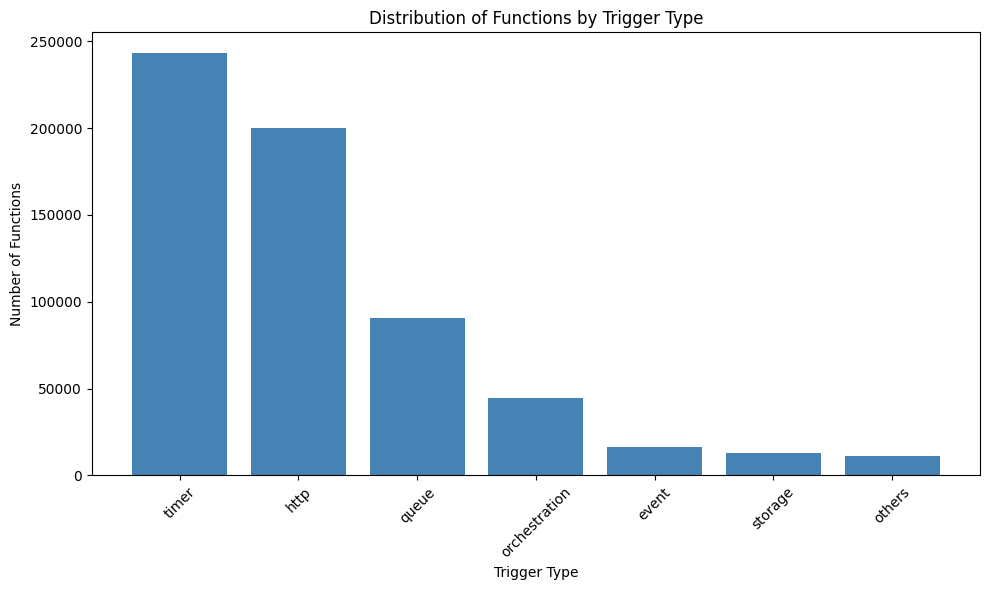

In [13]:
import matplotlib.pyplot as plt

trigger_counts = function_summary_df['Trigger'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(trigger_counts.index, trigger_counts.values, color='steelblue')
plt.xlabel('Trigger Type')
plt.ylabel('Number of Functions')
plt.title('Distribution of Functions by Trigger Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Key Insights: Trigger Type Distribution**

- Timer and HTTP triggers dominate, together making up over 70 percent of all functions
- Queue triggers form a moderate share, indicating common use of asynchronous processing
- Orchestration, event, storage, and other triggers are relatively rare, reflecting more specialized workloads
- The sharp drop after the top two categories shows most serverless usage follows simple scheduled or request-driven patterns

## **Step 2.4: Invocation Volume Distribution**

Since total invocation counts are highly skewed, as observed in the summary statistics, we visualize the distribution on a logarithmic scale. This reveals the true spread of workload intensity across functions, ranging from rarely invoked functions to extremely high-traffic ones.

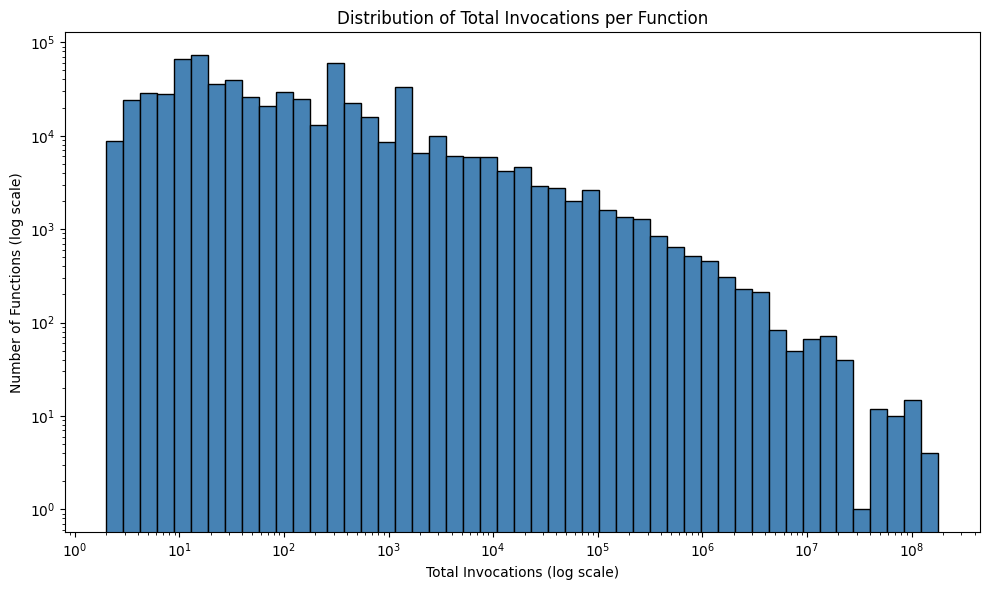

In [14]:
import numpy as np

log_bins = np.logspace(
    np.log10(function_summary_df['total_invocations'].min()),
    np.log10(function_summary_df['total_invocations'].max()),
    50
)

plt.figure(figsize=(10, 6))
plt.hist(function_summary_df['total_invocations'], bins=log_bins, color='steelblue', edgecolor='black')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Total Invocations (log scale)')
plt.ylabel('Number of Functions (log scale)')
plt.title('Distribution of Total Invocations per Function')
plt.tight_layout()
plt.show()

### **Key Insights: Invocation Volume Distribution**

- Invocation counts follow a heavy-tailed distribution, with most functions clustered in the low-to-moderate range (10 to 1,000 invocations per day)
- A large peak occurs around 10 to 100 invocations, showing this is the most common workload intensity for serverless functions
- The number of functions steadily declines as invocation volume increases, following a pattern typical of real-world cloud workloads
- A small number of functions reach extremely high invocation counts (above 10 million), representing high-traffic, mission-critical services
- This confirms that serverless cost and scaling strategies must account for a few high-volume functions alongside a much larger base of low-traffic functions

## **Step 2.5: Application-Level Invocation Patterns**

We now shift from individual function-level analysis to application-level patterns. This helps us understand how functions are grouped within applications and whether invocation load is concentrated in a small number of applications or spread evenly.

In [15]:
app_summary_df = function_summary_df.groupby('HashApp').agg(
    function_count=('HashFunction', 'count'),
    total_app_invocations=('total_invocations', 'sum'),
    avg_invocations_per_function=('total_invocations', 'mean')
).reset_index()

print("Shape:", app_summary_df.shape)
print("\nSummary statistics:")
app_summary_df[['function_count', 'total_app_invocations', 'avg_invocations_per_function']].describe()

Shape: (24274, 4)

Summary statistics:


,function_count,total_app_invocations,avg_invocations_per_function
count,24274.000000,2.427400e+04,2.427400e+04
mean,25.481791,5.149690e+05,1.942150e+04
std,55.941367,1.667414e+07,5.515852e+05
min,1.000000,2.000000e+00,2.000000e+00
25%,6.000000,1.190000e+02,1.266667e+01
50%,14.000000,1.247000e+03,6.400000e+01
75%,28.000000,8.448750e+03,4.755462e+02
max,3855.000000,1.800298e+09,6.667769e+07


### **Key Insights: Application-Level Patterns**

- The dataset contains 24,274 applications, with a median of 14 functions per application
- Some applications contain over 3,800 functions, showing large and complex serverless architectures exist alongside simple single-function apps
- Total invocations per application are extremely skewed, with a median of about 1,247 but a maximum exceeding 1.8 billion
- The gap between median and maximum total invocations confirms that a small number of applications drive the majority of overall serverless traffic
- This concentration pattern is important for cost modeling, since infrastructure planning must prioritize a few high-load applications over the long tail of low-usage ones

## **Step 2.6: Distribution of Function Count per Application**

This visualization shows how many functions typically exist within a single application, helping identify whether most applications are simple (few functions) or complex (many functions).

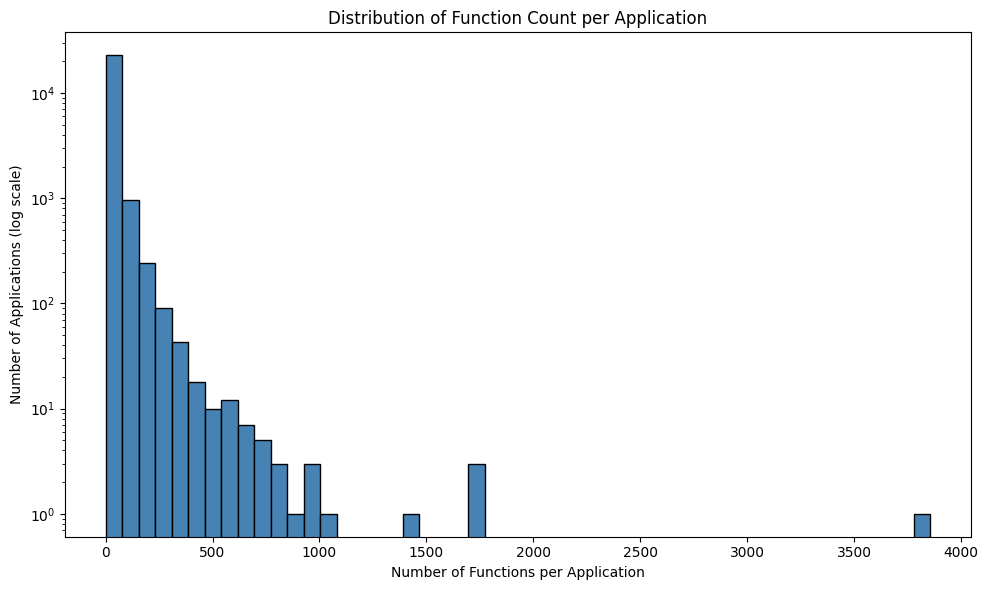

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(app_summary_df['function_count'], bins=50, color='steelblue', edgecolor='black')
plt.yscale('log')
plt.xlabel('Number of Functions per Application')
plt.ylabel('Number of Applications (log scale)')
plt.title('Distribution of Function Count per Application')
plt.tight_layout()
plt.show()

### **Key Insights: Function Count Distribution per Application**

- The vast majority of applications contain fewer than 100 functions, confirming most serverless applications are simple in structure
- Only a small number of applications scale beyond 500 functions, representing complex, enterprise-level deployments
- A handful of extreme outliers exceed 1,500 to 3,800 functions, likely representing large platform-level or multi-service applications
- This right-skewed pattern is consistent with the invocation volume distribution, reinforcing that a small subset of applications account for both high complexity and high traffic

# **Step 3: Loading Function Duration and Memory Data**

This section begins Objective 3 by loading the two remaining datasets: function execution duration percentiles and application memory usage percentiles. These datasets provide the performance and resource dimensions needed to engineer cost-related features, complementing the invocation frequency data already analyzed.

In [17]:
import pandas as pd
duration_df = pd.read_feather('azure_2019_data/azure-functions-dataset-2019/function_durations_percentiles.feather')
memory_df = pd.read_feather('azure_2019_data/azure-functions-dataset-2019/app_memory_percentiles.feather')

print("Duration data shape:", duration_df.shape)
print("Duration columns:", duration_df.columns.tolist())
print("\nMemory data shape:", memory_df.shape)
print("Memory columns:", memory_df.columns.tolist())

print("\nDuration data preview:")
print(duration_df.head())

print("\nMemory data preview:")
print(memory_df.head())

Duration data shape: (662927, 15)
Duration columns: ['HashOwner', 'HashApp', 'HashFunction', 'Average', 'Count', 'Minimum', 'Maximum', 'percentile_Average_0', 'percentile_Average_1', 'percentile_Average_25', 'percentile_Average_50', 'percentile_Average_75', 'percentile_Average_99', 'percentile_Average_100', 'day']

Memory data shape: (206809, 13)
Memory columns: ['HashOwner', 'HashApp', 'SampleCount', 'AverageAllocatedMb', 'AverageAllocatedMb_pct1', 'AverageAllocatedMb_pct5', 'AverageAllocatedMb_pct25', 'AverageAllocatedMb_pct50', 'AverageAllocatedMb_pct75', 'AverageAllocatedMb_pct95', 'AverageAllocatedMb_pct99', 'AverageAllocatedMb_pct100', 'day']

Duration data preview:
                                           HashOwner  \
0  5640c1597ef75fa9a7e9c6925022a039a4ba9829241709...   
1  5640c1597ef75fa9a7e9c6925022a039a4ba9829241709...   
2  41d6e09d0f86f5aaa1df842c1ac4f14fbd4dc676bec7e0...   
3  e117b8c1676e11d859824b18fc0202ae8eaa89cb3f58e2...   
4  3c8c13c6bd162490dae4402bcb9ff1e5c6c1

## **Step 3.1: Aggregating Duration and Memory Data**

Both the duration and memory datasets contain multiple daily records per function or application. To create a single representative feature set, we aggregate these records by averaging key metrics across all available days for each function and application.

In [18]:
duration_agg_df = duration_df.groupby(['HashOwner', 'HashApp', 'HashFunction']).agg(
    avg_duration_ms=('Average', 'mean'),
    min_duration_ms=('Minimum', 'mean'),
    max_duration_ms=('Maximum', 'mean'),
    p50_duration_ms=('percentile_Average_50', 'mean'),
    p99_duration_ms=('percentile_Average_99', 'mean'),
    execution_count=('Count', 'sum')
).reset_index()

memory_agg_df = memory_df.groupby(['HashOwner', 'HashApp']).agg(
    avg_memory_mb=('AverageAllocatedMb', 'mean'),
    p50_memory_mb=('AverageAllocatedMb_pct50', 'mean'),
    p95_memory_mb=('AverageAllocatedMb_pct95', 'mean'),
    max_memory_mb=('AverageAllocatedMb_pct100', 'mean')
).reset_index()

print("Duration aggregated shape:", duration_agg_df.shape)
print("Memory aggregated shape:", memory_agg_df.shape)

print("\nDuration aggregated preview:")
print(duration_agg_df.head())

print("\nMemory aggregated preview:")
print(memory_agg_df.head())

Duration aggregated shape: (82375, 9)
Memory aggregated shape: (23961, 6)

Duration aggregated preview:
                                           HashOwner  \
0  0001edd756889b6f8ad48f9d7c03fe42d5bc3deabed9d7...   
1  0001edd756889b6f8ad48f9d7c03fe42d5bc3deabed9d7...   
2  0001edd756889b6f8ad48f9d7c03fe42d5bc3deabed9d7...   
3  0001edd756889b6f8ad48f9d7c03fe42d5bc3deabed9d7...   
4  0001edd756889b6f8ad48f9d7c03fe42d5bc3deabed9d7...   

                                             HashApp  \
0  4c5c62b1da65cdd9c5e987a8235ab3b3a74d7229603100...   
1  4c5c62b1da65cdd9c5e987a8235ab3b3a74d7229603100...   
2  4c5c62b1da65cdd9c5e987a8235ab3b3a74d7229603100...   
3  4c5c62b1da65cdd9c5e987a8235ab3b3a74d7229603100...   
4  4c5c62b1da65cdd9c5e987a8235ab3b3a74d7229603100...   

                                        HashFunction  avg_duration_ms  \
0  0691cf2b03ca11b9cf0685a65dca4dd82a464770769812...       228.428571   
1  16330433665207657c499cba276f4d73a74b12c2b1b2d1...       261.000000   
2  

## **Step 3.2: Merging Datasets into a Unified Feature Table**

We now combine the invocation summary, execution duration, and memory allocation datasets into a single table using HashFunction and HashApp as join keys. Since memory data is only available at the application level, it is merged using HashApp. This unified table forms the foundation for feature engineering and model building.

In [19]:
merged_df = function_summary_df.merge(
    duration_agg_df,
    on=['HashOwner', 'HashApp', 'HashFunction'],
    how='inner'
)

merged_df = merged_df.merge(
    memory_agg_df,
    on=['HashOwner', 'HashApp'],
    how='left'
)

print("Merged dataset shape:", merged_df.shape)
print("\nMissing values per column:")
print(merged_df.isnull().sum())

print("\nFirst 5 rows:")
merged_df.head()

Merged dataset shape: (611147, 17)

Missing values per column:
HashOwner                      0
HashApp                        0
HashFunction                   0
Trigger                        0
total_invocations              0
avg_invocations_per_min        0
max_invocations_per_min        0
avg_duration_ms                0
min_duration_ms                0
max_duration_ms                0
p50_duration_ms                0
p99_duration_ms                0
execution_count                0
avg_memory_mb              12067
p50_memory_mb              12067
p95_memory_mb              12067
max_memory_mb              12067
dtype: int64

First 5 rows:


,HashOwner,HashApp,HashFunction,Trigger,total_invocations,avg_invocations_per_min,max_invocations_per_min,avg_duration_ms,min_duration_ms,max_duration_ms,p50_duration_ms,p99_duration_ms,execution_count,avg_memory_mb,p50_memory_mb,p95_memory_mb,max_memory_mb
0,71ca12c7af70d021e285b51b245942f8432df6463ff9f2...,7ca324d9fc836a5d4562811c11ce3719530ee919dd1fb9...,520dbd6bd906840012aa0c4b778743efc7c0ac7b7caf96...,http,289,0.200694,1,40.000000,11.500000,1763.500000,30.428571,161.071429,4032,106.083333,106.833333,107.25,108.000000
1,71ca12c7af70d021e285b51b245942f8432df6463ff9f2...,0d0ac65651f54ae3285a59564d64e39238b516fa1d5b56...,115ca7a2b5bc290052c3da74cd0347d19c3c67b7d5aa66...,http,289,0.200694,1,29.857143,7.500000,903.142857,27.357143,68.214286,4032,124.916667,125.000000,134.75,145.583333
2,71ca12c7af70d021e285b51b245942f8432df6463ff9f2...,a04487a6ba1e14296eb7647e4963180d28bef7a90a8fc5...,93e6c664773bbec3a7f50a0e92fa7e97401a802dc6eed8...,orchestration,11,0.007639,1,418.384615,247.307692,1033.230769,291.692308,1032.615385,103,127.833333,127.583333,144.25,159.083333
3,71ca12c7af70d021e285b51b245942f8432df6463ff9f2...,a04487a6ba1e14296eb7647e4963180d28bef7a90a8fc5...,740c5c767e4b9978ee59a97d1829cfbaf755a47806a311...,http,12,0.008333,1,1732.181818,314.909091,6597.818182,739.727273,6414.909091,92,127.833333,127.583333,144.25,159.083333
4,71ca12c7af70d021e285b51b245942f8432df6463ff9f2...,a04487a6ba1e14296eb7647e4963180d28bef7a90a8fc5...,c108b4864b866b38b80d0e4594cc6d038f39668b804a1b...,http,10,0.006944,1,160.076923,86.692308,428.307692,112.384615,392.076923,106,127.833333,127.583333,144.25,159.083333


## **Step 3.3: Handling Missing Values**

Approximately 2 percent of rows are missing memory allocation data, since not all applications in the invocation dataset have corresponding memory records. Given the small proportion of missing data, we remove these rows to maintain a clean and complete feature set for modeling.

In [20]:
before_count = merged_df.shape[0]
merged_df = merged_df.dropna()
after_count = merged_df.shape[0]

print(f"Rows before: {before_count}")
print(f"Rows after: {after_count}")
print(f"Rows removed: {before_count - after_count} ({(before_count - after_count) / before_count * 100:.2f} percent)")

print("\nFinal missing values check:")
print(merged_df.isnull().sum().sum())

print("\nFinal merged dataset shape:", merged_df.shape)

Rows before: 611147
Rows after: 599080
Rows removed: 12067 (1.97 percent)

Final missing values check:
0

Final merged dataset shape: (599080, 17)


### **Key Insights: Dataset Merging and Cleaning**

- Invocation, duration, and memory datasets were successfully combined into a single unified table using function and application identifiers
- Only 1.97 percent of rows were removed due to missing memory data, preserving 599,080 complete records for analysis
- The final dataset now captures three critical dimensions of serverless workloads: how often functions run, how long they take, and how much memory they consume
- This unified structure directly supports Objective 3, since these combined metrics form the foundation for engineering cost and performance-related features

## **Step 3.4: Engineering Cost and Performance Features**

This section addresses Objective 3 directly by creating new features that approximate real-world serverless cost and performance characteristics. Cloud providers typically bill based on the combination of invocation count, execution duration, and memory allocation. We construct a cost proxy metric using this principle, along with additional performance indicators such as duration variability.

In [21]:
merged_df['gb_seconds'] = (merged_df['avg_memory_mb'] / 1024) * (merged_df['avg_duration_ms'] / 1000)
merged_df['estimated_cost_proxy'] = merged_df['total_invocations'] * merged_df['gb_seconds']
merged_df['duration_variability'] = merged_df['max_duration_ms'] - merged_df['min_duration_ms']
merged_df['duration_p99_p50_ratio'] = merged_df['p99_duration_ms'] / (merged_df['p50_duration_ms'] + 1)

print("New features added:")
print(merged_df[['gb_seconds', 'estimated_cost_proxy', 'duration_variability', 'duration_p99_p50_ratio']].describe())

print("\nFirst 5 rows with new features:")
merged_df[['HashFunction', 'total_invocations', 'avg_duration_ms', 'avg_memory_mb', 'gb_seconds', 'estimated_cost_proxy']].head()

New features added:
          gb_seconds  estimated_cost_proxy  duration_variability  \
count  599080.000000          5.990800e+05          5.990800e+05   
mean        2.082854          4.419586e+03          2.015583e+04   
std        10.097244          4.387821e+05          8.825971e+04   
min        -0.548986         -3.079388e+01          0.000000e+00   
25%         0.027816          1.494932e+00          3.611250e+02   
50%         0.135454          9.204352e+00          2.788909e+03   
75%         0.649013          6.352270e+01          1.313457e+04   
max       586.257730          2.508980e+08          1.269739e+07   

       duration_p99_p50_ratio  
count           599080.000000  
mean                51.284201  
std                790.048442  
min                  0.000000  
25%                  1.458573  
50%                  3.610678  
75%                 11.353191  
max             300121.000000  

First 5 rows with new features:


,HashFunction,total_invocations,avg_duration_ms,avg_memory_mb,gb_seconds,estimated_cost_proxy
0,520dbd6bd906840012aa0c4b778743efc7c0ac7b7caf96...,289,40.000000,106.083333,0.004144,1.197581
1,115ca7a2b5bc290052c3da74cd0347d19c3c67b7d5aa66...,289,29.857143,124.916667,0.003642,1.052608
2,93e6c664773bbec3a7f50a0e92fa7e97401a802dc6eed8...,11,418.384615,127.833333,0.052230,0.574530
3,740c5c767e4b9978ee59a97d1829cfbaf755a47806a311...,12,1732.181818,127.833333,0.216241,2.594890
4,c108b4864b866b38b80d0e4594cc6d038f39668b804a1b...,10,160.076923,127.833333,0.019984,0.199836


## **Step 3.5: Identifying and Removing Invalid Records**

Since gb_seconds is a product of memory and duration, both inherently positive quantities, any negative values indicate data recording errors in the original trace. Before proceeding to modeling, we identify and remove these invalid records to ensure the integrity of our target variable and features.

In [22]:
invalid_rows = merged_df[merged_df['gb_seconds'] < 0]
print(f"Number of invalid rows: {invalid_rows.shape[0]}")
print(f"Percentage of dataset: {invalid_rows.shape[0] / merged_df.shape[0] * 100:.4f} percent")

print("\nSample of invalid rows:")
invalid_rows[['HashFunction', 'avg_duration_ms', 'avg_memory_mb', 'gb_seconds']].head()

Number of invalid rows: 42
Percentage of dataset: 0.0070 percent

Sample of invalid rows:


,HashFunction,avg_duration_ms,avg_memory_mb,gb_seconds
11582,0a02b4bf42c4dd6cb850deb718dbea4fd087debd04b571...,-2763.083333,203.454545,-0.548986
11586,158ff6b725be4bc5aafc3fbdd053280c2d11c84a83174e...,-2672.200000,203.454545,-0.530929
11587,57021857e126cc53481f4caa189a2826206f9d644c5fb2...,-148.200000,203.454545,-0.029445
11588,4fdd0e554459472920ffb7a0e35b525710919685cbed8f...,-2459.400000,203.454545,-0.488649
57405,0a02b4bf42c4dd6cb850deb718dbea4fd087debd04b571...,-2763.083333,203.454545,-0.548986


## **Step 3.6: Finalizing the Clean Feature Set**

We remove the 42 records containing negative duration values, which represent a negligible 0.007 percent of the dataset. This ensures all engineered features, particularly the cost proxy metric, are mathematically valid before proceeding to model development.

In [23]:
before_count = merged_df.shape[0]
merged_df = merged_df[merged_df['gb_seconds'] >= 0].reset_index(drop=True)
after_count = merged_df.shape[0]

print(f"Rows before: {before_count}")
print(f"Rows after: {after_count}")
print(f"Rows removed: {before_count - after_count}")

print("\nFinal feature set summary:")
merged_df[['total_invocations', 'avg_duration_ms', 'avg_memory_mb', 'gb_seconds', 'estimated_cost_proxy']].describe()

Rows before: 599080
Rows after: 599038
Rows removed: 42

Final feature set summary:


,total_invocations,avg_duration_ms,avg_memory_mb,gb_seconds,estimated_cost_proxy
count,5.990380e+05,599038.000000,599038.000000,599038.000000,5.990380e+05
mean,2.067062e+04,11038.401428,169.638021,2.083029,4.419897e+03
std,8.625305e+05,41678.916823,69.588961,10.097576,4.387975e+05
min,2.000000e+00,0.000000,44.166667,0.000000,0.000000e+00
25%,1.200000e+01,180.714286,125.416667,0.027831,1.495636e+00
50%,4.200000e+01,864.500000,158.333333,0.135501,9.206142e+00
75%,3.010000e+02,4073.000000,191.583333,0.649058,6.353271e+01
max,1.805548e+08,634969.142857,1368.285714,586.257730,2.508980e+08


### **Key Insights: Cost and Performance Feature Engineering**

- A cost proxy metric was constructed by combining invocation frequency, execution duration, and memory allocation, mirroring real-world serverless billing models
- Estimated cost values are highly skewed, ranging from near zero to over 250 million units, reflecting the same long-tail pattern seen in invocation volume
- Average execution duration varies widely across functions, from near-instant responses to over 600 seconds, indicating diverse workload types
- Memory allocation is comparatively more stable, mostly ranging between 125 and 192 MB for the middle 50 percent of functions
- A small number of corrupted records with negative duration values were identified and removed, ensuring the reliability of all cost-related calculations
- The finalized feature set of 599,038 records is now ready for correlation analysis and predictive modeling

## **Step 3.7: Correlation Analysis**

Before building a predictive model, we examine the relationships between engineered features and the target variable, estimated cost proxy. This helps identify which features carry the strongest predictive signal and reveals any multicollinearity between features.

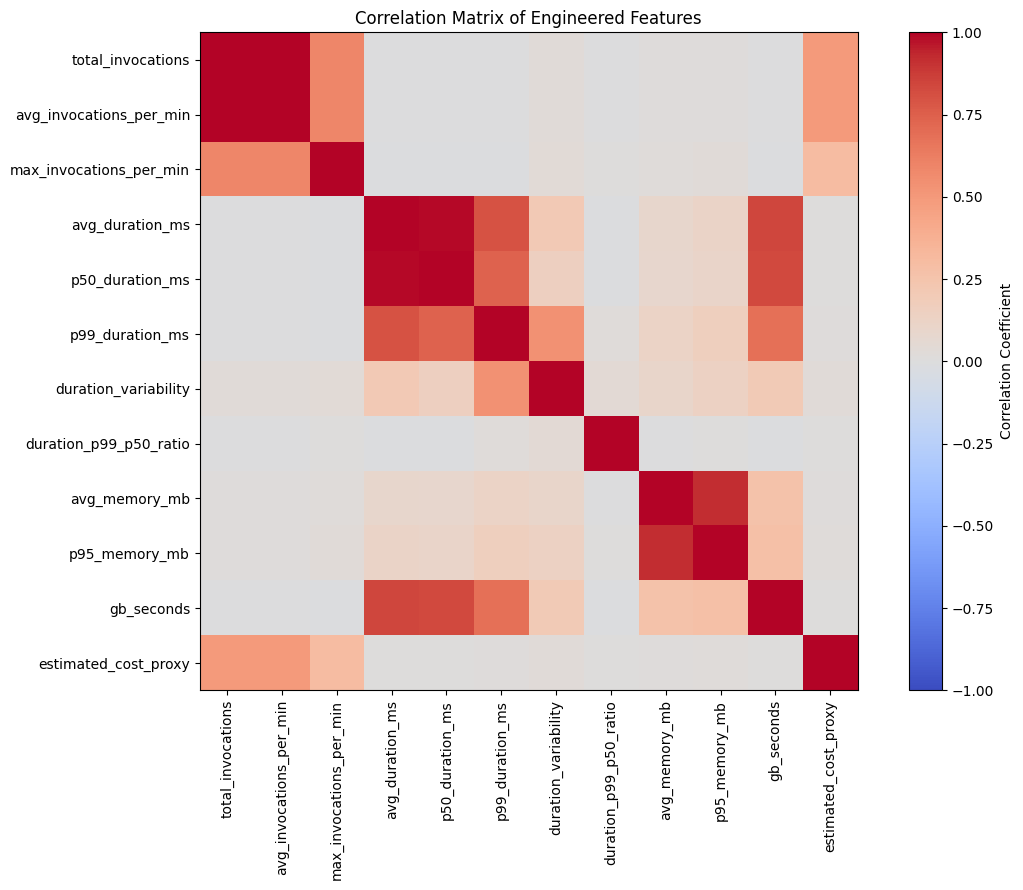

Correlation with estimated_cost_proxy:
estimated_cost_proxy       1.000000
avg_invocations_per_min    0.494898
total_invocations          0.494898
max_invocations_per_min    0.299666
duration_variability       0.027219
p95_memory_mb              0.020026
avg_memory_mb              0.014860
p99_duration_ms            0.008492
gb_seconds                 0.004018
avg_duration_ms            0.002957
p50_duration_ms            0.002184
duration_p99_p50_ratio     0.000494
Name: estimated_cost_proxy, dtype: float64


In [24]:
feature_columns = [
    'total_invocations', 'avg_invocations_per_min', 'max_invocations_per_min',
    'avg_duration_ms', 'p50_duration_ms', 'p99_duration_ms', 'duration_variability',
    'duration_p99_p50_ratio', 'avg_memory_mb', 'p95_memory_mb', 'gb_seconds',
    'estimated_cost_proxy'
]

correlation_matrix = merged_df[feature_columns].corr()

plt.figure(figsize=(12, 9))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(feature_columns)), feature_columns, rotation=90)
plt.yticks(range(len(feature_columns)), feature_columns)
plt.title('Correlation Matrix of Engineered Features')
plt.tight_layout()
plt.show()

print("Correlation with estimated_cost_proxy:")
print(correlation_matrix['estimated_cost_proxy'].sort_values(ascending=False))

### **Key Insights: Feature Correlation Analysis**

- Total invocations and average invocations per minute show the strongest positive relationship with estimated cost, confirming that invocation frequency is the primary cost driver
- Duration-related features, such as average and median duration, are strongly correlated with each other but show weak direct correlation with the final cost proxy
- Memory-related features are moderately correlated with each other but contribute less independently to overall cost
- Gb_seconds, despite combining duration and memory, shows weak correlation with the final cost proxy, since invocation volume dominates the cost calculation at this scale
- These results suggest that invocation frequency will be the most influential predictor in the upcoming model, with duration and memory acting as secondary contributing factors

# **Step 4: Preparing Data for Modeling**

This section begins Objective 4, building a predictive model for function workload cost. We select relevant features, separate the target variable, and split the data into training and testing sets to evaluate model performance on unseen data.

In [25]:
from sklearn.model_selection import train_test_split

feature_cols = [
    'total_invocations', 'avg_invocations_per_min', 'max_invocations_per_min',
    'avg_duration_ms', 'p50_duration_ms', 'p99_duration_ms', 'duration_variability',
    'avg_memory_mb', 'p95_memory_mb'
]

X = merged_df[feature_cols]
y = merged_df['estimated_cost_proxy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nTarget variable range in training set:")
print(y_train.describe())

Training set shape: (479230, 9)
Testing set shape: (119808, 9)

Target variable range in training set:
count    4.792300e+05
mean     4.809538e+03
std      4.835705e+05
min      0.000000e+00
25%      1.499945e+00
50%      9.201202e+00
75%      6.350038e+01
max      2.508980e+08
Name: estimated_cost_proxy, dtype: float64


## **Step 4.1: Log-Transforming the Target Variable**

The target variable, estimated cost proxy, is highly right-skewed, spanning from near zero to over 250 million. Training a model directly on this scale would cause the model to focus disproportionately on extreme high-cost functions. We apply a log transformation to compress this range and produce a more stable target distribution for training.

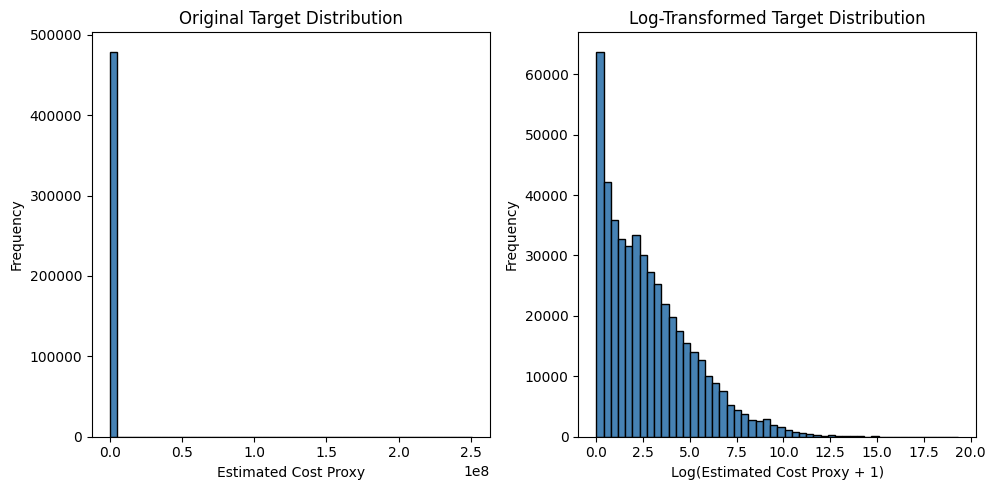

In [26]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(y_train, bins=50, color='steelblue', edgecolor='black')
plt.title('Original Target Distribution')
plt.xlabel('Estimated Cost Proxy')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(y_train_log, bins=50, color='steelblue', edgecolor='black')
plt.title('Log-Transformed Target Distribution')
plt.xlabel('Log(Estimated Cost Proxy + 1)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### **Key Insights: Target Variable Transformation**

- The original cost proxy distribution is extremely concentrated near zero, with a long tail extending to over 250 million
- After log transformation, the distribution becomes much more balanced and closer to a normal shape
- This transformation prevents the model from being disproportionately influenced by a small number of extremely high-cost functions
- Predictions will be made in log space and converted back to the original scale for interpretation

## **Step 4.2: Training a Random Forest Regression Model**

We train a Random Forest Regressor to predict the log-transformed cost proxy using the engineered invocation, duration, and memory features. Random Forest is well suited for this task since it captures non-linear relationships and provides interpretable feature importance scores.

In [27]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train_log)

print("Model training complete")
print(f"Number of trees: {model.n_estimators}")
print(f"Max depth: {model.max_depth}")

Model training complete
Number of trees: 100
Max depth: 15


## **Step 4.3: Evaluating Model Performance**

We evaluate the trained model on the held-out test set using standard regression metrics: R-squared, Mean Absolute Error, and Root Mean Squared Error. These metrics are computed in log space, where the model was trained, to provide a fair and stable assessment of predictive performance.

In [28]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred_log = model.predict(X_test)

r2 = r2_score(y_test_log, y_pred_log)
mae = mean_absolute_error(y_test_log, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))

print("Model Performance Metrics (Log Scale):")
print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

Model Performance Metrics (Log Scale):
R-squared: 0.9993
Mean Absolute Error: 0.0390
Root Mean Squared Error: 0.0606


## **Step 4.4: Rebuilding the Feature Set to Remove Data Leakage**

The previous model achieved an unrealistically high R-squared because duration and memory features were used to predict a target that was directly derived from them. To build a genuinely predictive model, we restrict the feature set to invocation pattern data and trigger type only, information that would realistically be available when estimating the cost impact of a function based on its calling pattern. Trigger type is converted into numeric form using one-hot encoding.

In [29]:
trigger_dummies = pd.get_dummies(merged_df['Trigger'], prefix='trigger')

X_clean = pd.concat([
    merged_df[['total_invocations', 'avg_invocations_per_min', 'max_invocations_per_min']],
    trigger_dummies
], axis=1)

y_clean = merged_df['estimated_cost_proxy']

print("Feature columns:", X_clean.columns.tolist())
print("\nFeature set shape:", X_clean.shape)
X_clean.head()

Feature columns: ['total_invocations', 'avg_invocations_per_min', 'max_invocations_per_min', 'trigger_event', 'trigger_http', 'trigger_orchestration', 'trigger_others', 'trigger_queue', 'trigger_storage', 'trigger_timer']

Feature set shape: (599038, 10)


,total_invocations,avg_invocations_per_min,max_invocations_per_min,trigger_event,trigger_http,trigger_orchestration,trigger_others,trigger_queue,trigger_storage,trigger_timer
0,289,0.200694,1,False,True,False,False,False,False,False
1,289,0.200694,1,False,True,False,False,False,False,False
2,11,0.007639,1,False,False,True,False,False,False,False
3,12,0.008333,1,False,True,False,False,False,False,False
4,10,0.006944,1,False,True,False,False,False,False,False


## **Step 4.5: Splitting Data and Retraining the Model**

We split the leakage-free feature set into training and testing sets, apply the same log transformation to the target variable, and retrain the Random Forest model. This provides an honest evaluation of how well invocation frequency and trigger type alone can predict function cost.

In [30]:
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

y_train_clean_log = np.log1p(y_train_clean)
y_test_clean_log = np.log1p(y_test_clean)

model_clean = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model_clean.fit(X_train_clean, y_train_clean_log)

print("Training set shape:", X_train_clean.shape)
print("Testing set shape:", X_test_clean.shape)
print("Model training complete")

Training set shape: (479230, 10)
Testing set shape: (119808, 10)
Model training complete


## **Step 4.6: Evaluating the Leakage-Free Model**

We evaluate the retrained model on the test set using the same metrics as before. Since duration and memory features have been removed, we expect a more realistic and honest performance score that reflects how predictable cost truly is from invocation patterns alone.

In [31]:
y_pred_clean_log = model_clean.predict(X_test_clean)

r2_clean = r2_score(y_test_clean_log, y_pred_clean_log)
mae_clean = mean_absolute_error(y_test_clean_log, y_pred_clean_log)
rmse_clean = np.sqrt(mean_squared_error(y_test_clean_log, y_pred_clean_log))

print("Model Performance Metrics (Log Scale):")
print(f"R-squared: {r2_clean:.4f}")
print(f"Mean Absolute Error: {mae_clean:.4f}")
print(f"Root Mean Squared Error: {rmse_clean:.4f}")

Model Performance Metrics (Log Scale):
R-squared: 0.4785
Mean Absolute Error: 1.3125
Root Mean Squared Error: 1.6981


### **Key Insights: Leakage-Free Model Performance**

- After removing duration and memory features, the model achieves an R-squared of 0.4785, meaning invocation patterns and trigger type explain nearly half the variance in function cost
- This is a realistic and meaningful result, since cost in serverless computing also depends on execution duration and memory allocation, factors not known in advance for a new function
- The result confirms that invocation frequency carries genuine predictive signal, but is not sufficient alone to fully determine cost
- This finding has practical value: it shows that historical invocation patterns can provide an early, partial estimate of expected cost before a function is deployed

## **Step 4.7: Visualizing Model Predictions and Feature Importance**

We visualize predicted versus actual values to assess how well the model captures the overall trend, and examine feature importance scores to understand which invocation characteristics contribute most to cost prediction.

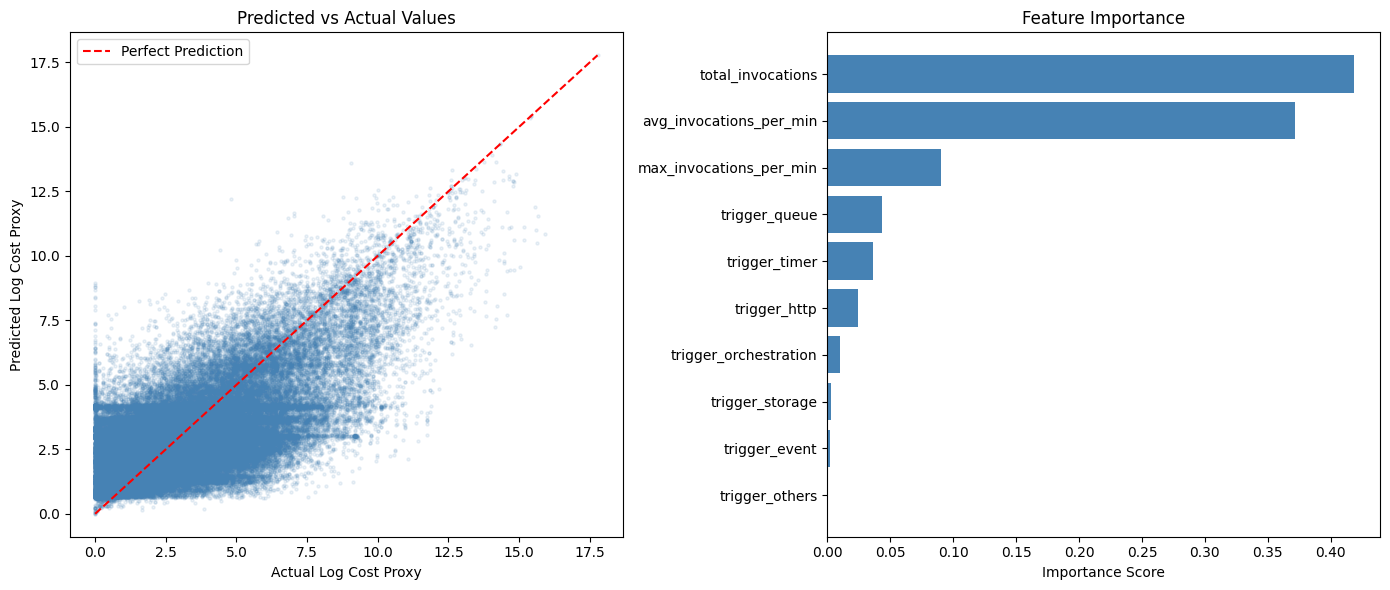

                   feature  importance
0        total_invocations    0.418234
1  avg_invocations_per_min    0.371975
2  max_invocations_per_min    0.090282
7            trigger_queue    0.043166
9            trigger_timer    0.036394
4             trigger_http    0.024529
5    trigger_orchestration    0.009979
8          trigger_storage    0.002891
3            trigger_event    0.001975
6           trigger_others    0.000574


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test_clean_log, y_pred_clean_log, alpha=0.1, s=5, color='steelblue')
axes[0].plot([y_test_clean_log.min(), y_test_clean_log.max()],
             [y_test_clean_log.min(), y_test_clean_log.max()],
             color='red', linestyle='--', label='Perfect Prediction')
axes[0].set_xlabel('Actual Log Cost Proxy')
axes[0].set_ylabel('Predicted Log Cost Proxy')
axes[0].set_title('Predicted vs Actual Values')
axes[0].legend()

importance_df = pd.DataFrame({
    'feature': X_clean.columns,
    'importance': model_clean.feature_importances_
}).sort_values('importance', ascending=False)

axes[1].barh(importance_df['feature'], importance_df['importance'], color='steelblue')
axes[1].set_xlabel('Importance Score')
axes[1].set_title('Feature Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(importance_df)

### **Key Insights: Model Predictions and Feature Importance**

- Predicted values follow the general trend of actual values, with tighter alignment at lower cost levels and more spread at higher cost levels
- The model tends to underpredict extremely high-cost functions, suggesting rare high-traffic functions have cost drivers beyond invocation frequency alone
- Total invocations and average invocations per minute together account for nearly 80 percent of the model's predictive power
- Trigger type contributes modestly to predictions, with queue and timer triggers showing slightly more influence than others
- These results confirm that invocation volume is the dominant signal for cost estimation, while execution context, such as memory and duration, likely explains the remaining unexplained variance

## **Project Summary**

This project analyzed real-world serverless computing workload data from the Azure Functions 2019 public trace to understand invocation patterns and build a predictive model for estimating function-level cost.

### **What Was Done**
- Loaded and processed a large-scale dataset covering over 600,000 serverless functions using memory-efficient techniques to handle scale constraints
- Analyzed invocation frequency, trigger type distribution, and application-level workload patterns
- Engineered a cost proxy metric based on invocation frequency, execution duration, and memory allocation, reflecting real-world serverless billing principles
- Identified and corrected data quality issues, including corrupted duration values
- Built a Random Forest regression model to predict function cost from invocation patterns and trigger type
- Ensured the model was free of data leakage by excluding features that were directly used to construct the target variable

### **Key Findings**
- Serverless workloads are highly skewed, with a small number of functions and applications responsible for the majority of invocation volume and cost
- Invocation frequency is the strongest available predictor of function cost, explaining nearly half the variance even without duration or memory information
- Trigger type provides secondary predictive value, with queue and timer-based functions showing distinct cost patterns compared to others

### **Relevance**
This project demonstrates the practical application of data analysis and machine learning to cloud computing workload characterization, a core theme in cloud resource management and performance modeling research. It reflects the ability to work with large-scale, real-world system traces, engineer domain-relevant features, and build predictive models while maintaining methodological rigor.